# TPC 7x7 Patch Shape Study: Ripple Candidates, Double Peaks, and Edge-Heavy Patches

This notebook examines every saved 7x7 TPC patch and creates reproducible shape-based review groups.

## Main questions

1. Which patches contain two or more significant local peaks?
2. Which patches carry substantial ADC on their outer boundary?
3. Which patches resemble a centered ripple: one central maximum followed by generally decreasing ADC rings?

> **Important:** These are morphology-based candidate rules, not truth labels. A ripple-shaped patch is not automatically a real signal, and a double-peak or edge-heavy patch is not automatically fake. The resulting galleries and CSV files are intended for professor review and later validation with simulation or labeled data.


## 1. Imports, Files, and Adjustable Parameters

The parameters below are intentionally collected in one place. Change them, rerun the notebook, and compare the resulting candidate galleries and counts.


In [1]:
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.22
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

TPC_DIR = Path("/Users/user/Documents/Autoencoder TPC")
INPUT_CSV = TPC_DIR / "outputs_7x7_filter" / "all_patches_7x7_with_diagnostics.csv"
OUTPUT_DIR = TPC_DIR / "outputs_ripple_analysis"
OUTPUT_DIR.mkdir(exist_ok=True)

PATCH_SIZE = 7
CENTER = PATCH_SIZE // 2

# Edge rules
EDGE_ZERO_TOLERANCE = 0.0       # Strict ripple: every outer-edge pixel must be <= this value.
EDGE_HEAVY_FRACTION = 0.25      # Edge-heavy: at least 25% of total ADC lies on the outer edge.
LOOSE_EDGE_FRACTION = 0.05      # Loose ripple: allow up to 5% of total ADC on the edge.

# Peak rules
PEAK_RELATIVE_HEIGHT = 0.35     # Ignore regional maxima below 35% of the patch maximum.
PEAK_MIN_PROMINENCE = 5.0       # Peak must exceed its surrounding boundary by at least 5 ADC.
DOUBLE_PEAK_SECOND_RATIO = 0.55 # Second peak must be at least 55% of the strongest peak.

# Ripple trend and connectedness rules
RING_RELATIVE_TOLERANCE = 0.10  # Allow the next ring mean to rise by at most 10%.
RING_ABSOLUTE_TOLERANCE = 2.0   # Also allow a small absolute ADC increase.
STRICT_RADIAL_CORR_MAX = -0.45  # More negative means ADC falls more strongly with distance.
LOOSE_RADIAL_CORR_MAX = -0.25
STRICT_CONNECTED_FRACTION = 0.85
LOOSE_CONNECTED_FRACTION = 0.70
MIN_NONZERO_PIXELS = 4
MAX_NONZERO_PIXELS = 24
STRICT_RING1_MIN_NONZERO = 4       # Require signal around the center, not only along one ray.
STRICT_HALFPLANE_COVERAGE = 4      # Require signal above, below, left, and right of center.
STRICT_ROTATIONAL_ASYMMETRY_MAX = 0.50

print("Input:", INPUT_CSV)
print("Output folder:", OUTPUT_DIR)


Input: /Users/user/Documents/Autoencoder TPC/outputs_7x7_filter/all_patches_7x7_with_diagnostics.csv
Output folder: /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis


## 2. Load All 7x7 Patches

The input table contains the original 49 ADC pixels plus event, layer, center coordinates, and earlier diagnostics. This notebook recomputes the shape metrics so their definitions remain explicit.


In [2]:
patches = pd.read_csv(INPUT_CSV)
pixel_cols = [f"p{i:02d}" for i in range(PATCH_SIZE * PATCH_SIZE)]

missing = [col for col in pixel_cols if col not in patches.columns]
if missing:
    raise ValueError(f"Missing patch pixel columns: {missing}")

pixels = patches[pixel_cols].to_numpy(dtype=np.float32).reshape(-1, PATCH_SIZE, PATCH_SIZE)

print(f"Loaded patches: {len(patches):,}")
print("Pixel array shape:", pixels.shape)
print("Events:", sorted(patches["event"].unique()))
print("Layer range:", int(patches["layer"].min()), "to", int(patches["layer"].max()))


Loaded patches: 42,256
Pixel array shape: (42256, 7, 7)
Events: [np.int64(74)]
Layer range: 3 to 54


## 3. Measurable Shape Definitions

### Edge-heavy

The outer boundary contains at least 25% of the patch's total ADC:

$$f_{edge}=rac{\sum ADC_{edge}}{\sum ADC_{patch}}\ge 0.25$$

### Double peak

A regional maximum is a pixel or connected plateau that:

- is not lower than any of its eight neighbors,
- is at least 35% of the patch maximum, and
- exceeds its surrounding boundary by at least 5 ADC.

A patch is called double-peak when it contains at least two significant regional maxima and the second peak is at least 55% as high as the strongest peak.

### Ripple candidate

Pixels are grouped into square rings using Chebyshev distance from the center:

- Ring 0: center pixel
- Ring 1: eight pixels surrounding the center
- Ring 2: next 16 pixels
- Ring 3: outer 24 pixels

A strict ripple candidate must have one centered peak, a zero outer edge, one mostly connected nonzero region, and ring-average ADC values that do not increase as distance from the center grows. To reject one-directional line shapes, the strict rule also requires signal on all four sides of the center, at least four active pixels in Ring 1, and limited 180-degree asymmetry.


## 4. Shape-Analysis Helper Functions


In [3]:
NEIGHBORS_8 = [
    (dr, dc)
    for dr in (-1, 0, 1)
    for dc in (-1, 0, 1)
    if not (dr == 0 and dc == 0)
]


def connected_components(mask):
    """Return 8-connected components from a small Boolean image."""
    mask = np.asarray(mask, dtype=bool)
    visited = np.zeros_like(mask, dtype=bool)
    components = []

    for start_r, start_c in np.argwhere(mask):
        if visited[start_r, start_c]:
            continue
        queue = deque([(int(start_r), int(start_c))])
        visited[start_r, start_c] = True
        component = []

        while queue:
            r, c = queue.popleft()
            component.append((r, c))
            for dr, dc in NEIGHBORS_8:
                nr, nc = r + dr, c + dc
                if 0 <= nr < PATCH_SIZE and 0 <= nc < PATCH_SIZE:
                    if mask[nr, nc] and not visited[nr, nc]:
                        visited[nr, nc] = True
                        queue.append((nr, nc))
        components.append(component)
    return components


def center_connected_fraction(patch):
    """Fraction of all nonzero pixels connected to the center through nonzero pixels."""
    active = patch > 0
    total = int(active.sum())
    if total == 0 or not active[CENTER, CENTER]:
        return 0.0

    queue = deque([(CENTER, CENTER)])
    visited = {(CENTER, CENTER)}
    while queue:
        r, c = queue.popleft()
        for dr, dc in NEIGHBORS_8:
            nr, nc = r + dr, c + dc
            if 0 <= nr < PATCH_SIZE and 0 <= nc < PATCH_SIZE:
                if active[nr, nc] and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    queue.append((nr, nc))
    return len(visited) / total


def significant_regional_peaks(patch):
    """Find regional maxima, joining adjacent equal-height peak pixels into one peak."""
    patch = np.asarray(patch, dtype=float)
    maximum = float(patch.max())
    if maximum <= 0:
        return []

    minimum_height = PEAK_RELATIVE_HEIGHT * maximum
    regional_mask = patch >= minimum_height

    padded = np.pad(patch, 1, mode="constant", constant_values=-np.inf)
    for dr, dc in NEIGHBORS_8:
        neighbor = padded[1 + dr:1 + dr + PATCH_SIZE, 1 + dc:1 + dc + PATCH_SIZE]
        regional_mask &= patch >= neighbor

    peaks = []
    for component in connected_components(regional_mask):
        component_set = set(component)
        peak_value = max(float(patch[r, c]) for r, c in component)
        surrounding = []
        for r, c in component:
            for dr, dc in NEIGHBORS_8:
                nr, nc = r + dr, c + dc
                if 0 <= nr < PATCH_SIZE and 0 <= nc < PATCH_SIZE:
                    if (nr, nc) not in component_set:
                        surrounding.append(float(patch[nr, nc]))
        boundary_max = max(surrounding) if surrounding else 0.0
        prominence = peak_value - boundary_max
        if prominence >= PEAK_MIN_PROMINENCE:
            representative = min(component, key=lambda rc: (rc[0] - CENTER) ** 2 + (rc[1] - CENTER) ** 2)
            peaks.append({
                "row": representative[0],
                "col": representative[1],
                "value": peak_value,
                "prominence": prominence,
                "plateau_pixels": len(component),
            })
    return sorted(peaks, key=lambda item: item["value"], reverse=True)


ring_index = np.fromfunction(
    lambda r, c: np.maximum(np.abs(r - CENTER), np.abs(c - CENTER)),
    (PATCH_SIZE, PATCH_SIZE),
    dtype=int,
).astype(int)

edge_mask = ring_index == CENTER
distance_flat = ring_index.reshape(-1).astype(float)
distance_centered = distance_flat - distance_flat.mean()
distance_norm = np.sqrt(np.sum(distance_centered ** 2))


def ring_means(patch):
    return np.array([patch[ring_index == radius].mean() for radius in range(CENTER + 1)], dtype=float)


def ring_decrease_score(means):
    """Fraction of the three ring transitions that are non-increasing within tolerance."""
    checks = []
    for inner, outer in zip(means[:-1], means[1:]):
        limit = inner * (1 + RING_RELATIVE_TOLERANCE) + RING_ABSOLUTE_TOLERANCE
        checks.append(outer <= limit)
    return float(np.mean(checks))


def radial_correlation(patch):
    """Correlation between distance from center and log ADC across all 49 pixels."""
    values = np.log1p(np.asarray(patch, dtype=float).reshape(-1))
    centered = values - values.mean()
    value_norm = np.sqrt(np.sum(centered ** 2))
    if value_norm == 0:
        return 0.0
    return float(np.sum(distance_centered * centered) / (distance_norm * value_norm))


## 5. Compute Shape Metrics for Every Patch

This is the slowest cell because it examines the connectivity and regional maxima of every 7x7 image.


In [4]:
total_adc = pixels.sum(axis=(1, 2))
edge_adc = pixels[:, edge_mask].sum(axis=1)
edge_nonzero = (pixels[:, edge_mask] > EDGE_ZERO_TOLERANCE).sum(axis=1)
ring1_nonzero = ((pixels > 0) & (ring_index == 1)).sum(axis=(1, 2))
halfplane_coverage = np.column_stack([
    (pixels[:, :CENTER, :] > 0).any(axis=(1, 2)),
    (pixels[:, CENTER + 1:, :] > 0).any(axis=(1, 2)),
    (pixels[:, :, :CENTER] > 0).any(axis=(1, 2)),
    (pixels[:, :, CENTER + 1:] > 0).any(axis=(1, 2)),
]).sum(axis=1)
rotated_pixels = pixels[:, ::-1, ::-1]
rotational_asymmetry = np.divide(
    np.abs(pixels - rotated_pixels).sum(axis=(1, 2)),
    2 * total_adc,
    out=np.zeros_like(total_adc, dtype=float),
    where=total_adc > 0,
)

metrics = []
for index, patch in enumerate(pixels):
    peaks = significant_regional_peaks(patch)
    means = ring_means(patch)
    peak_values = [item["value"] for item in peaks]
    strongest = peak_values[0] if peak_values else 0.0
    second = peak_values[1] if len(peak_values) >= 2 else 0.0

    metrics.append({
        "shape_row": index,
        "significant_peak_count": len(peaks),
        "strongest_peak_adc": strongest,
        "second_peak_adc": second,
        "second_peak_ratio": second / strongest if strongest > 0 else 0.0,
        "center_is_global_max": bool(patch[CENTER, CENTER] >= patch.max()),
        "center_connected_fraction": center_connected_fraction(patch),
        "ring0_mean": means[0],
        "ring1_mean": means[1],
        "ring2_mean": means[2],
        "ring3_mean": means[3],
        "ring_decrease_score": ring_decrease_score(means),
        "radial_adc_correlation": radial_correlation(patch),
    })

shape_metrics = pd.DataFrame(metrics)
shape_metrics["edge_adc_sum_recomputed"] = edge_adc
shape_metrics["edge_adc_fraction_recomputed"] = np.divide(
    edge_adc,
    total_adc,
    out=np.zeros_like(edge_adc, dtype=float),
    where=total_adc > 0,
)
shape_metrics["edge_nonzero_pixels_recomputed"] = edge_nonzero
shape_metrics["edge_zero"] = edge_nonzero == 0
shape_metrics["ring1_nonzero_pixels"] = ring1_nonzero
shape_metrics["halfplane_coverage"] = halfplane_coverage
shape_metrics["rotational_asymmetry"] = rotational_asymmetry

analysis = pd.concat(
    [patches.reset_index(drop=True), shape_metrics.drop(columns="shape_row")],
    axis=1,
)

print(f"Metrics computed for {len(analysis):,} patches")
analysis[[
    "significant_peak_count", "second_peak_ratio", "edge_adc_fraction_recomputed",
    "center_connected_fraction", "ring_decrease_score", "radial_adc_correlation"
]].describe()


Metrics computed for 42,256 patches


,significant_peak_count,second_peak_ratio,edge_adc_fraction_recomputed,center_connected_fraction,ring_decrease_score,radial_adc_correlation
count,42256.000000,42256.000000,42256.000000,42256.000000,42256.000000,42256.000000
mean,1.187287,0.169399,0.129519,0.957213,0.959288,-0.479611
std,0.707112,0.315464,0.180876,0.142904,0.118283,0.160056
min,0.000000,0.000000,0.000000,0.035714,0.333333,-0.875002
25%,1.000000,0.000000,0.000000,1.000000,1.000000,-0.602432
50%,1.000000,0.000000,0.005194,1.000000,1.000000,-0.501257
75%,1.000000,0.000000,0.256410,1.000000,1.000000,-0.390497
max,8.000000,1.000000,0.995926,1.000000,1.000000,0.462743


## 6. Diagnostic Distributions Before Applying Ripple Rules


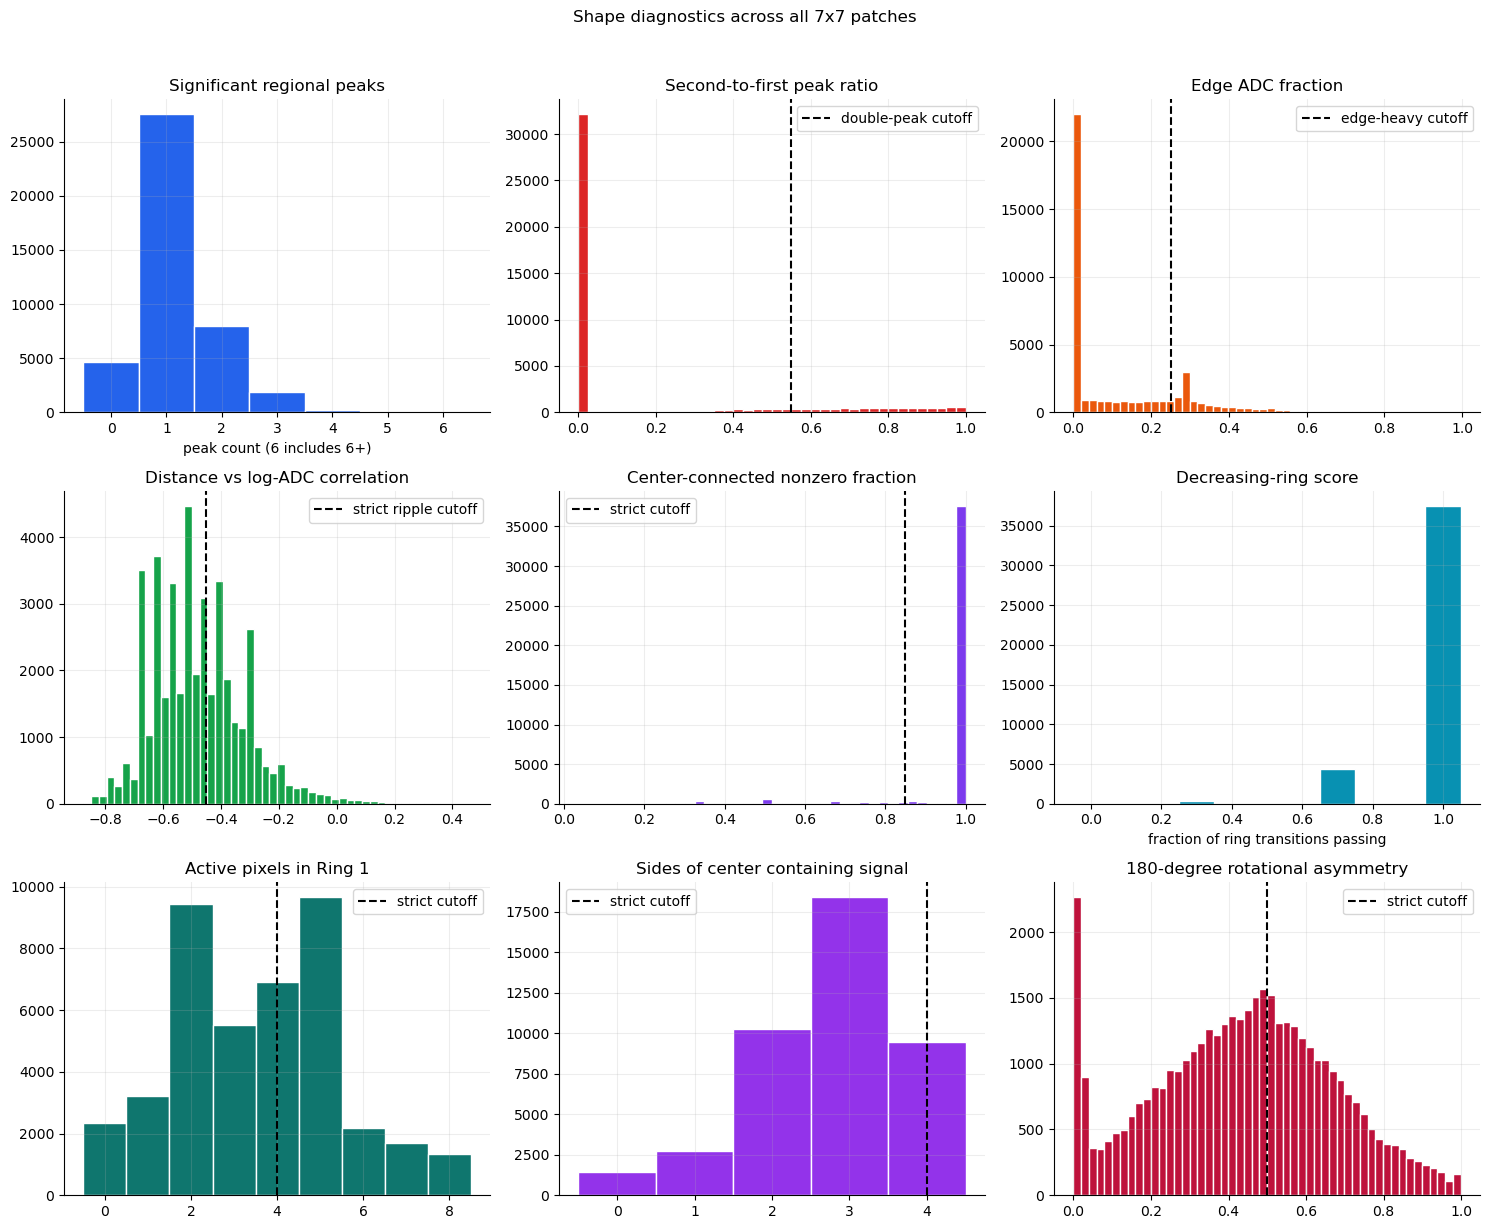

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

peak_bins = np.arange(-0.5, min(6, analysis["significant_peak_count"].max()) + 1.5, 1)
axes[0, 0].hist(analysis["significant_peak_count"].clip(upper=6), bins=peak_bins, color="#2563eb", edgecolor="white")
axes[0, 0].set_title("Significant regional peaks")
axes[0, 0].set_xlabel("peak count (6 includes 6+)")

axes[0, 1].hist(analysis["second_peak_ratio"], bins=40, color="#dc2626", edgecolor="white")
axes[0, 1].axvline(DOUBLE_PEAK_SECOND_RATIO, color="black", linestyle="--", label="double-peak cutoff")
axes[0, 1].set_title("Second-to-first peak ratio")
axes[0, 1].legend()

axes[0, 2].hist(analysis["edge_adc_fraction_recomputed"], bins=50, color="#ea580c", edgecolor="white")
axes[0, 2].axvline(EDGE_HEAVY_FRACTION, color="black", linestyle="--", label="edge-heavy cutoff")
axes[0, 2].set_title("Edge ADC fraction")
axes[0, 2].legend()

axes[1, 0].hist(analysis["radial_adc_correlation"], bins=50, color="#16a34a", edgecolor="white")
axes[1, 0].axvline(STRICT_RADIAL_CORR_MAX, color="black", linestyle="--", label="strict ripple cutoff")
axes[1, 0].set_title("Distance vs log-ADC correlation")
axes[1, 0].legend()

axes[1, 1].hist(analysis["center_connected_fraction"], bins=40, color="#7c3aed", edgecolor="white")
axes[1, 1].axvline(STRICT_CONNECTED_FRACTION, color="black", linestyle="--", label="strict cutoff")
axes[1, 1].set_title("Center-connected nonzero fraction")
axes[1, 1].legend()

axes[1, 2].hist(analysis["ring_decrease_score"], bins=np.linspace(-0.05, 1.05, 12), color="#0891b2", edgecolor="white")
axes[1, 2].set_title("Decreasing-ring score")
axes[1, 2].set_xlabel("fraction of ring transitions passing")

axes[2, 0].hist(analysis["ring1_nonzero_pixels"], bins=np.arange(-0.5, 9.5, 1), color="#0f766e", edgecolor="white")
axes[2, 0].axvline(STRICT_RING1_MIN_NONZERO, color="black", linestyle="--", label="strict cutoff")
axes[2, 0].set_title("Active pixels in Ring 1")
axes[2, 0].legend()

axes[2, 1].hist(analysis["halfplane_coverage"], bins=np.arange(-0.5, 5.5, 1), color="#9333ea", edgecolor="white")
axes[2, 1].axvline(STRICT_HALFPLANE_COVERAGE, color="black", linestyle="--", label="strict cutoff")
axes[2, 1].set_title("Sides of center containing signal")
axes[2, 1].legend()

axes[2, 2].hist(analysis["rotational_asymmetry"], bins=50, color="#be123c", edgecolor="white")
axes[2, 2].axvline(STRICT_ROTATIONAL_ASYMMETRY_MAX, color="black", linestyle="--", label="strict cutoff")
axes[2, 2].set_title("180-degree rotational asymmetry")
axes[2, 2].legend()

fig.suptitle("Shape diagnostics across all 7x7 patches", y=1.02)
fig.tight_layout()
plt.show()


## 7. Apply Strict and Loose Ripple Rules

The strict rule implements the proposed idea literally: all edge pixels are zero and the ring means decrease outward. The loose rule is useful for manual review because real detector clusters may be asymmetric, diffused, or slightly clipped.


In [6]:
analysis["double_peak"] = (
    (analysis["significant_peak_count"] >= 2)
    & (analysis["second_peak_ratio"] >= DOUBLE_PEAK_SECOND_RATIO)
)

analysis["edge_heavy_rule"] = analysis["edge_adc_fraction_recomputed"] >= EDGE_HEAVY_FRACTION

occupancy_ok = analysis["n_nonzero_pixels"].between(MIN_NONZERO_PIXELS, MAX_NONZERO_PIXELS)

analysis["strict_ripple"] = (
    analysis["edge_zero"]
    & (analysis["significant_peak_count"] == 1)
    & analysis["center_is_global_max"]
    & (analysis["ring_decrease_score"] == 1.0)
    & (analysis["radial_adc_correlation"] <= STRICT_RADIAL_CORR_MAX)
    & (analysis["center_connected_fraction"] >= STRICT_CONNECTED_FRACTION)
    & (analysis["ring1_nonzero_pixels"] >= STRICT_RING1_MIN_NONZERO)
    & (analysis["halfplane_coverage"] >= STRICT_HALFPLANE_COVERAGE)
    & (analysis["rotational_asymmetry"] <= STRICT_ROTATIONAL_ASYMMETRY_MAX)
    & occupancy_ok
)

analysis["loose_ripple"] = (
    (analysis["edge_adc_fraction_recomputed"] <= LOOSE_EDGE_FRACTION)
    & (analysis["significant_peak_count"] == 1)
    & analysis["center_is_global_max"]
    & (analysis["ring_decrease_score"] >= 2 / 3)
    & (analysis["radial_adc_correlation"] <= LOOSE_RADIAL_CORR_MAX)
    & (analysis["center_connected_fraction"] >= LOOSE_CONNECTED_FRACTION)
    & occupancy_ok
)

# A continuous score helps rank borderline candidates without pretending the rule is ground truth.
analysis["ripple_score"] = (
    (analysis["edge_adc_fraction_recomputed"] <= LOOSE_EDGE_FRACTION).astype(int)
    + (analysis["significant_peak_count"] == 1).astype(int)
    + analysis["center_is_global_max"].astype(int)
    + (analysis["ring_decrease_score"] >= 2 / 3).astype(int)
    + (analysis["radial_adc_correlation"] <= LOOSE_RADIAL_CORR_MAX).astype(int)
    + (analysis["center_connected_fraction"] >= LOOSE_CONNECTED_FRACTION).astype(int)
    + (analysis["ring1_nonzero_pixels"] >= 3).astype(int)
    + (analysis["halfplane_coverage"] >= 3).astype(int)
    + (analysis["rotational_asymmetry"] <= 0.65).astype(int)
    + occupancy_ok.astype(int)
)

summary = pd.DataFrame({
    "count": {
        "all patches": len(analysis),
        "strict ripple": int(analysis["strict_ripple"].sum()),
        "loose ripple": int(analysis["loose_ripple"].sum()),
        "double peak": int(analysis["double_peak"].sum()),
        "edge heavy": int(analysis["edge_heavy_rule"].sum()),
        "double peak AND edge heavy": int((analysis["double_peak"] & analysis["edge_heavy_rule"]).sum()),
    }
})
summary["fraction_of_all"] = summary["count"] / len(analysis)
summary


,count,fraction_of_all
all patches,42256,1.000000
strict ripple,1733,0.041012
loose ripple,15320,0.362552
double peak,7568,0.179099
edge heavy,10866,0.257147
double peak AND edge heavy,3870,0.091585


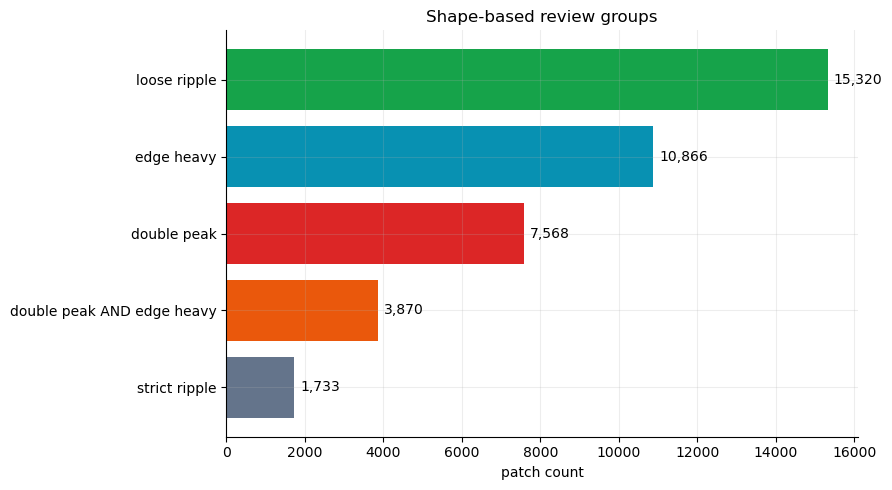

In [7]:
plot_summary = summary.drop(index="all patches").sort_values("count")
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#64748b", "#ea580c", "#dc2626", "#0891b2", "#16a34a"]
bars = ax.barh(plot_summary.index, plot_summary["count"], color=colors[:len(plot_summary)])
ax.set_xlabel("patch count")
ax.set_title("Shape-based review groups")
for bar, value in zip(bars, plot_summary["count"]):
    ax.text(value + max(plot_summary["count"]) * 0.01, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center")
fig.tight_layout()
plt.show()


## 8. Patch-Gallery Helper


In [8]:
def show_patch_gallery(table, title, n=16, sort_by=None, ascending=False, mark_peaks=False):
    if table.empty:
        print(f"No patches found for: {title}")
        return

    if sort_by is not None:
        display_table = table.sort_values(sort_by, ascending=ascending).head(n)
    else:
        display_table = table.sample(n=min(n, len(table)), random_state=74)

    n = len(display_table)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, display_table.iterrows()):
        patch = row[pixel_cols].to_numpy(dtype=float).reshape(PATCH_SIZE, PATCH_SIZE)
        ax.imshow(patch, cmap="viridis", origin="lower")
        if mark_peaks:
            for peak in significant_regional_peaks(patch):
                ax.scatter(peak["col"], peak["row"], facecolors="none", edgecolors="red", s=90, linewidths=1.5)
        ax.set_title(
            f"L{int(row['layer'])} t{int(row['center_tbin'])} | peaks {int(row['significant_peak_count'])}\n"
            f"edge {row['edge_adc_fraction_recomputed']:.2f} | corr {row['radial_adc_correlation']:.2f}",
            fontsize=9,
        )
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, y=1.01, fontsize=15)
    fig.tight_layout()
    plt.show()


## 9. Strict Ripple Candidates

These pass every strict rule. Inspect whether the group matches the professor's intended visual definition before treating the rule as final.


Strict ripple candidates: 1,733


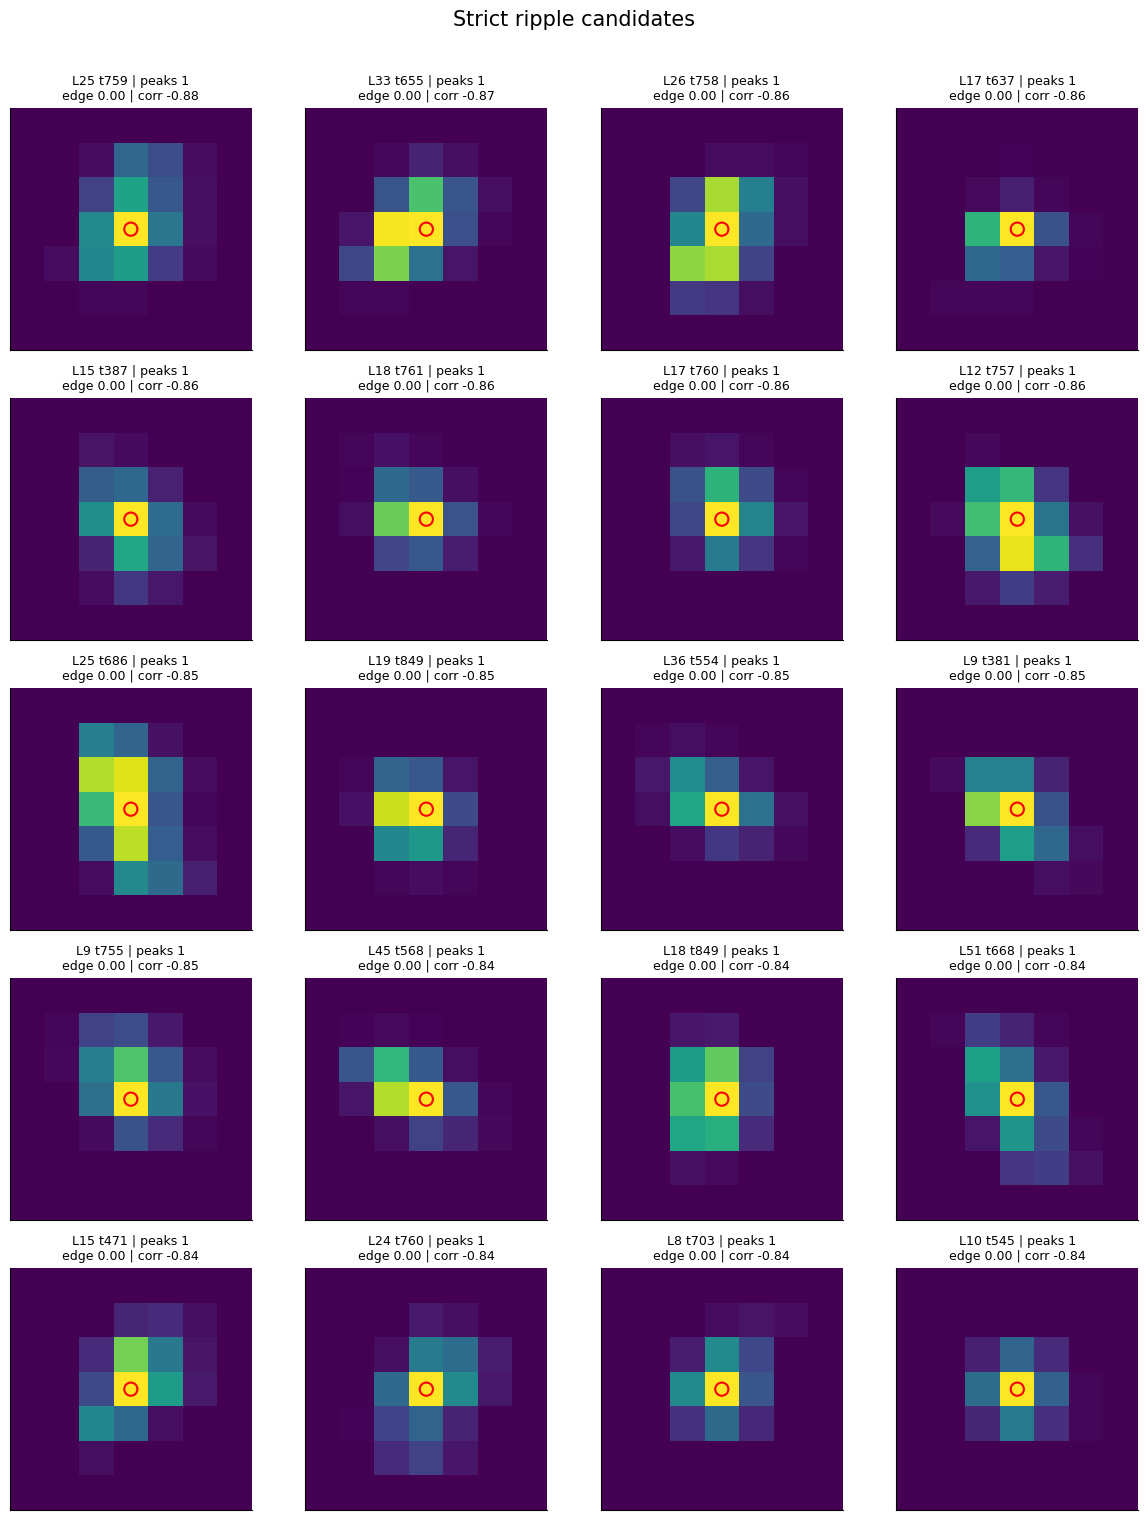

In [9]:
strict_ripples = analysis[analysis["strict_ripple"]].copy()
print(f"Strict ripple candidates: {len(strict_ripples):,}")
show_patch_gallery(
    strict_ripples,
    "Strict ripple candidates",
    n=20,
    sort_by=["ripple_score", "radial_adc_correlation"],
    ascending=[False, True],
    mark_peaks=True,
)


## 10. Loose Ripple Candidates for Manual Review

These allow small edge activity and two of three outward ring transitions to pass. They are useful for identifying valid ripple shapes rejected by an exact-zero edge requirement.


Loose ripple candidates: 15,320
Loose-only candidates: 13,587


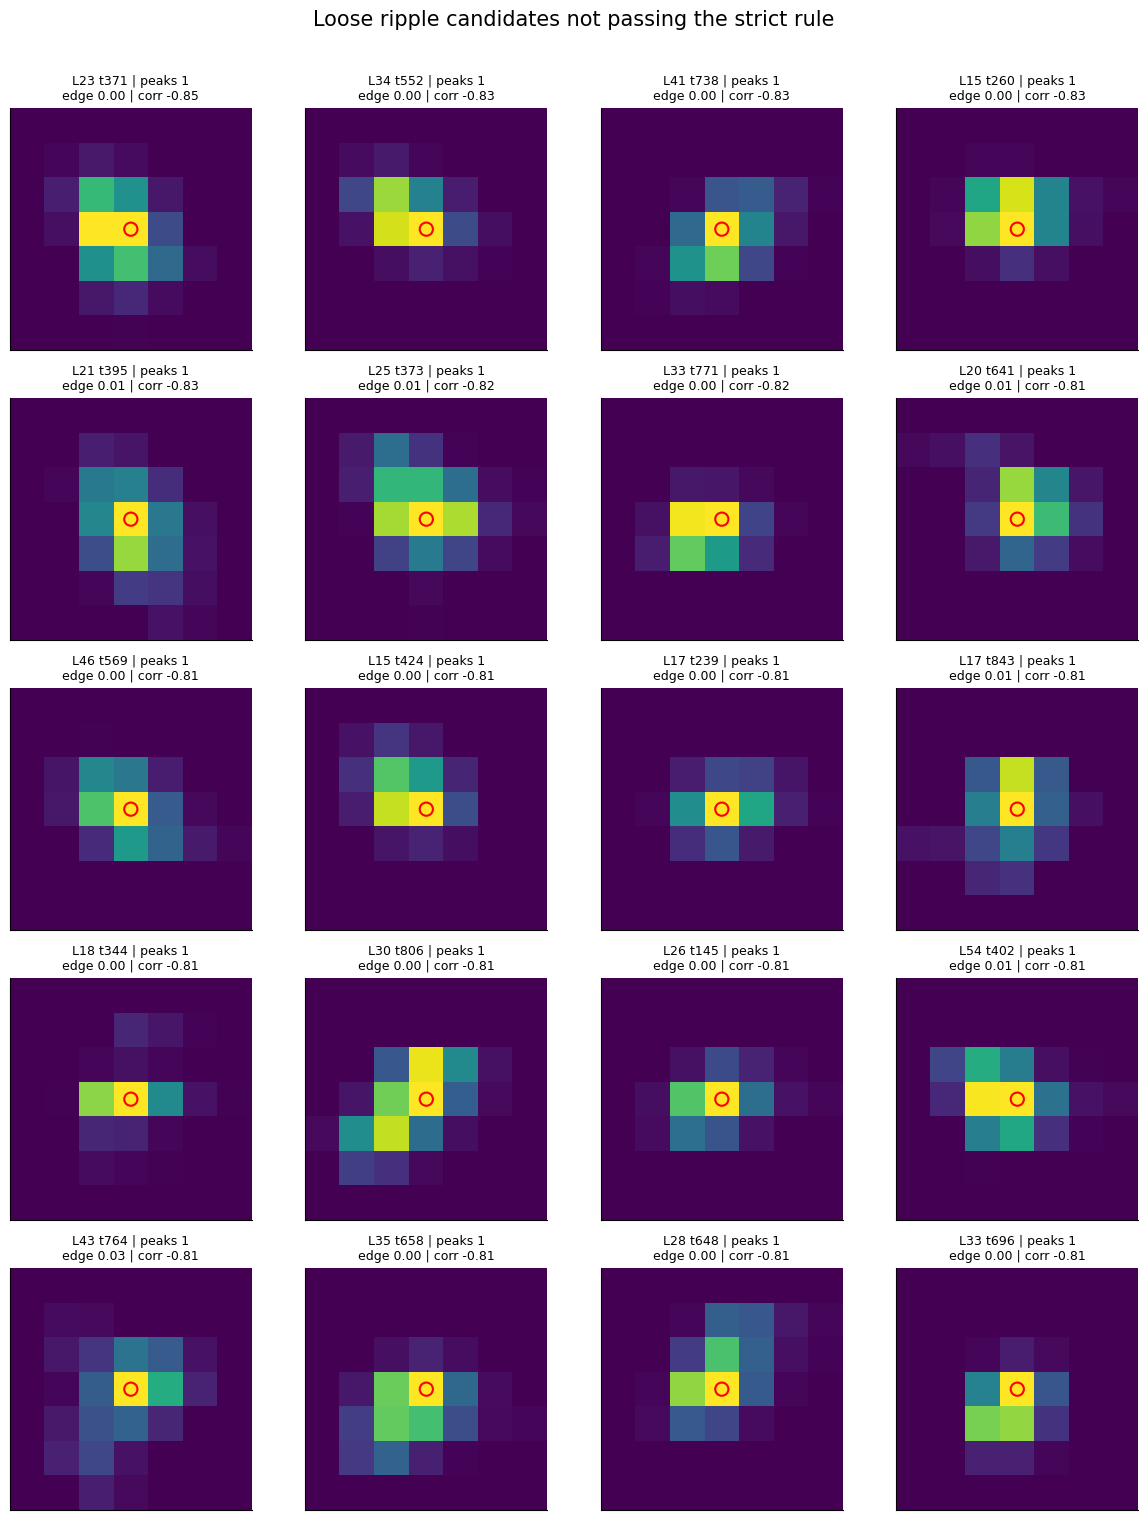

In [10]:
loose_ripples = analysis[analysis["loose_ripple"]].copy()
loose_only = loose_ripples[~loose_ripples["strict_ripple"]].copy()
print(f"Loose ripple candidates: {len(loose_ripples):,}")
print(f"Loose-only candidates: {len(loose_only):,}")
show_patch_gallery(
    loose_only,
    "Loose ripple candidates not passing the strict rule",
    n=20,
    sort_by=["ripple_score", "radial_adc_correlation"],
    ascending=[False, True],
    mark_peaks=True,
)


## 11. Double-Peak Patches

Red circles mark the significant regional maxima detected by the current rule. These patches should be inspected for overlapping clusters, track structure, electronics effects, or peak-counting artifacts.


Double-peak patches: 7,568


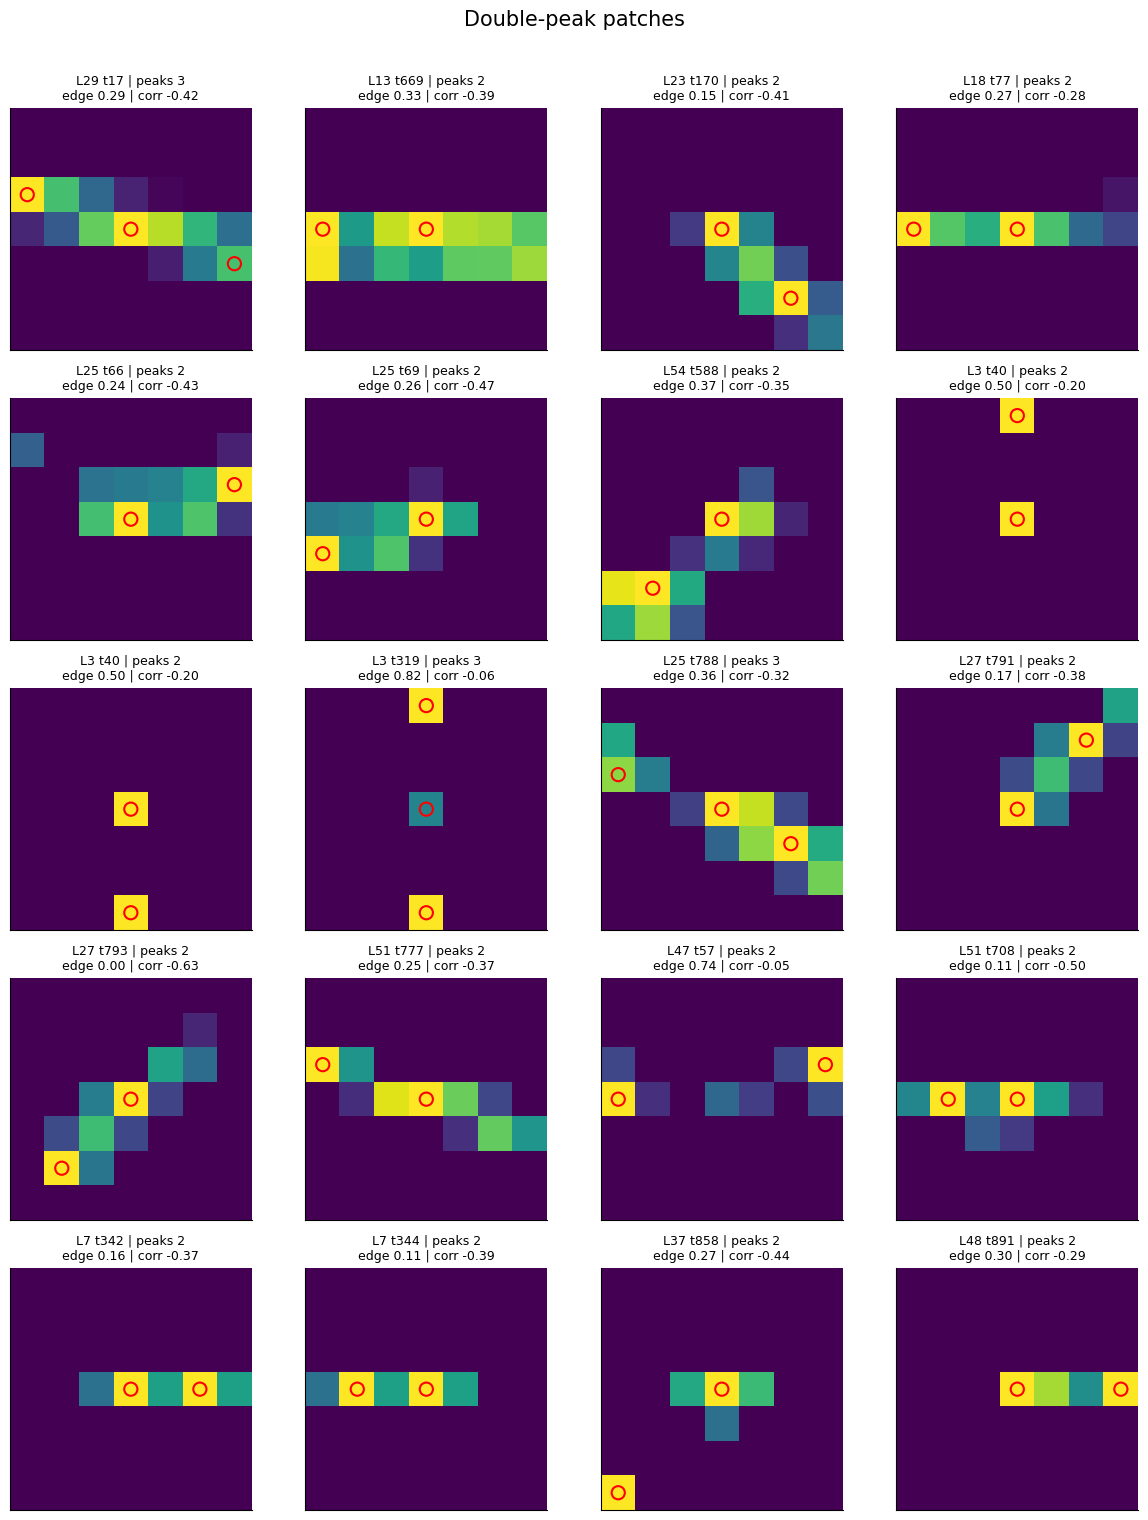

In [11]:
double_peaks = analysis[analysis["double_peak"]].copy()
print(f"Double-peak patches: {len(double_peaks):,}")
show_patch_gallery(
    double_peaks,
    "Double-peak patches",
    n=20,
    sort_by=["second_peak_ratio", "max_adc"],
    ascending=[False, False],
    mark_peaks=True,
)


## 12. Edge-Heavy Patches

These contain at least 25% of their total ADC on the outer boundary. Possible interpretations include a cluster extending beyond 7x7, a nearby second structure, an off-center maximum, or an artifact.


Edge-heavy patches: 10,866


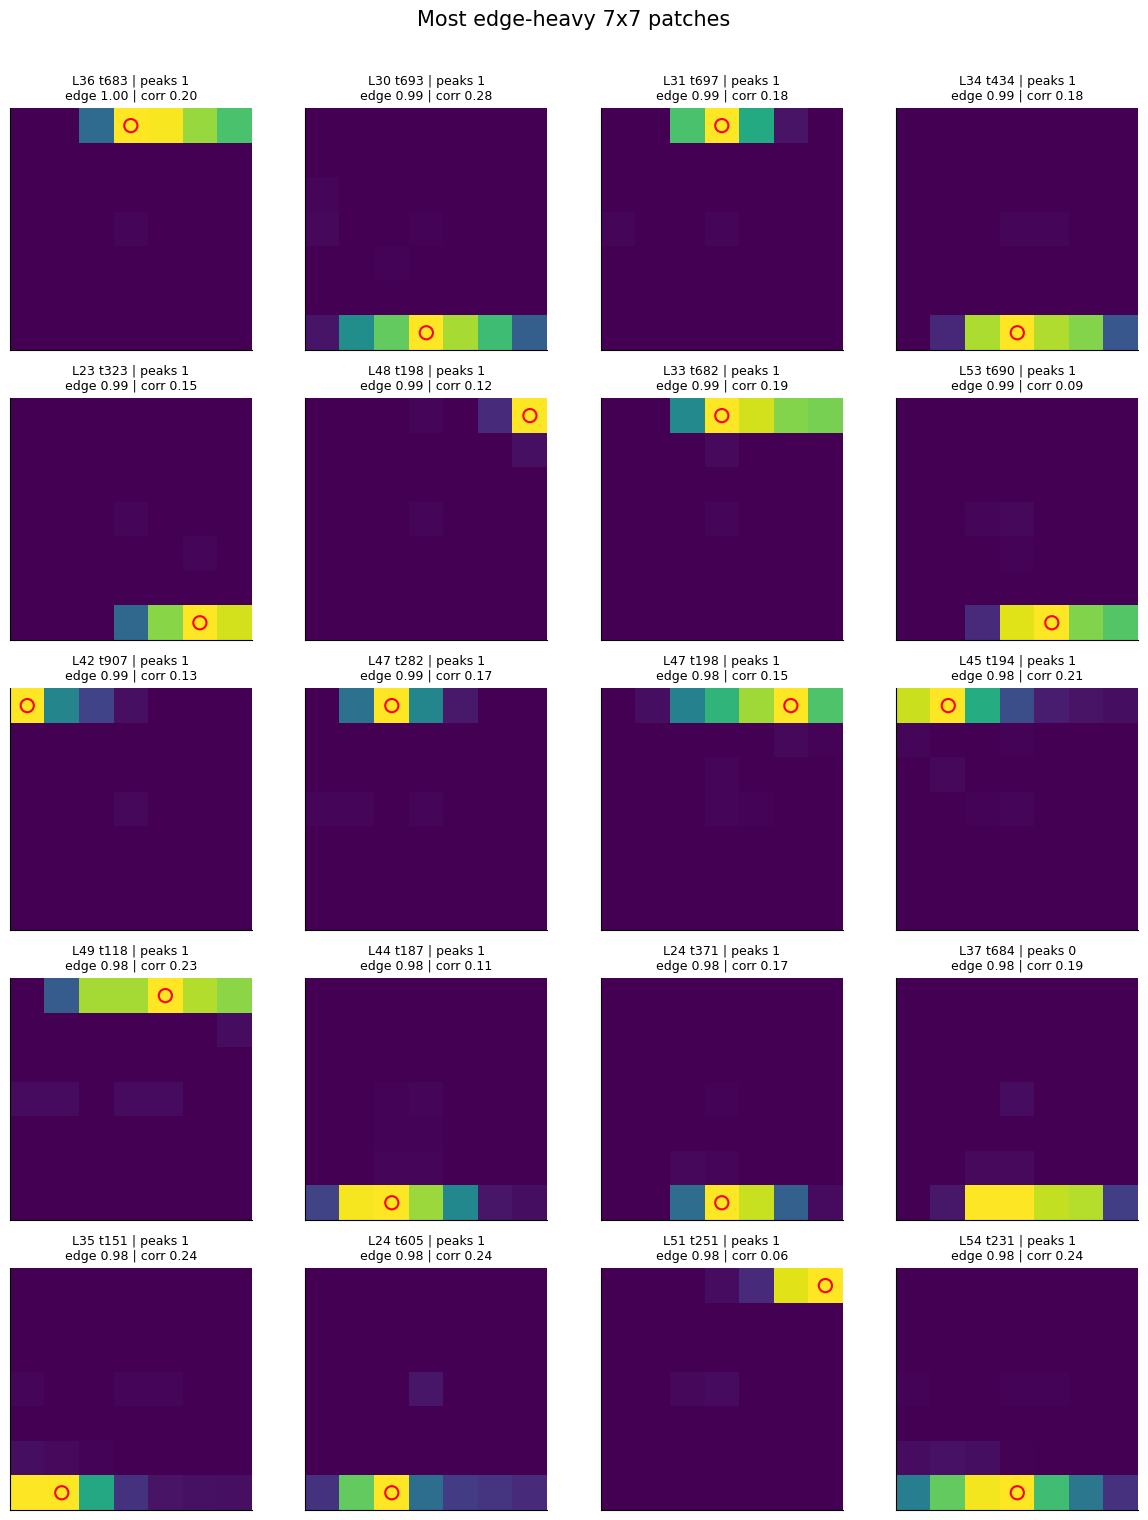

In [12]:
edge_heavy_patches = analysis[analysis["edge_heavy_rule"]].copy()
print(f"Edge-heavy patches: {len(edge_heavy_patches):,}")
show_patch_gallery(
    edge_heavy_patches,
    "Most edge-heavy 7x7 patches",
    n=20,
    sort_by="edge_adc_fraction_recomputed",
    ascending=False,
    mark_peaks=True,
)


## 13. Average Ring Profiles


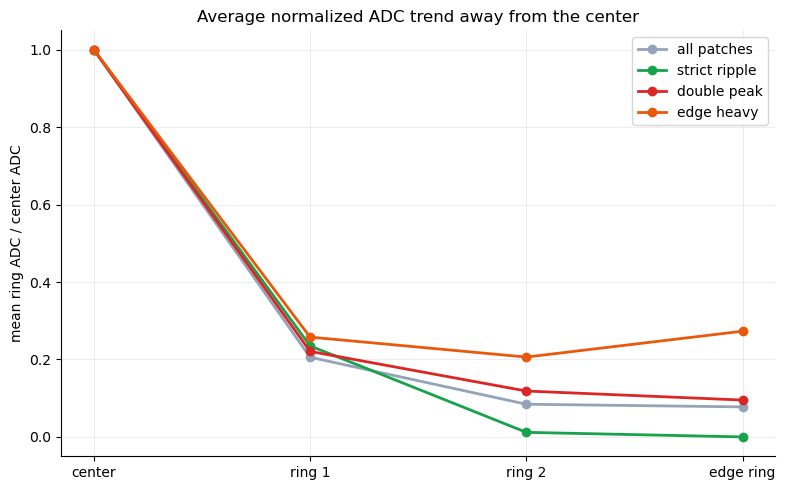

In [13]:
profile_columns = ["ring0_mean", "ring1_mean", "ring2_mean", "ring3_mean"]

fig, ax = plt.subplots(figsize=(8, 5))
for label, table, color in [
    ("all patches", analysis, "#94a3b8"),
    ("strict ripple", strict_ripples, "#16a34a"),
    ("double peak", double_peaks, "#dc2626"),
    ("edge heavy", edge_heavy_patches, "#ea580c"),
]:
    if table.empty:
        continue
    normalized_profiles = table[profile_columns].to_numpy(dtype=float)
    center = normalized_profiles[:, [0]]
    normalized_profiles = np.divide(
        normalized_profiles,
        center,
        out=np.zeros_like(normalized_profiles),
        where=center > 0,
    )
    ax.plot(range(4), np.nanmean(normalized_profiles, axis=0), marker="o", linewidth=2, label=label, color=color)

ax.set_xticks(range(4), ["center", "ring 1", "ring 2", "edge ring"])
ax.set_ylabel("mean ring ADC / center ADC")
ax.set_title("Average normalized ADC trend away from the center")
ax.legend()
fig.tight_layout()
plt.show()


## 14. Save Metrics and Candidate Groups

Every exported row retains the original 49 ADC pixels and metadata together with the new shape metrics. This makes it possible to trace a candidate back to its event, layer, phi, and time bin.


In [14]:
outputs = {
    "all_patches_with_shape_metrics.csv": analysis,
    "strict_ripple_patches_7x7.csv": strict_ripples,
    "loose_ripple_candidates_7x7.csv": loose_ripples,
    "double_peak_patches_7x7.csv": double_peaks,
    "edge_heavy_patches_7x7.csv": edge_heavy_patches,
    "double_peak_and_edge_heavy_7x7.csv": analysis[analysis["double_peak"] & analysis["edge_heavy_rule"]],
}

for filename, table in outputs.items():
    path = OUTPUT_DIR / filename
    table.to_csv(path, index=False)
    print(f"Saved {len(table):,} rows -> {path}")

summary.to_csv(OUTPUT_DIR / "shape_group_summary.csv")


Saved 42,256 rows -> /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis/all_patches_with_shape_metrics.csv
Saved 1,733 rows -> /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis/strict_ripple_patches_7x7.csv


Saved 15,320 rows -> /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis/loose_ripple_candidates_7x7.csv
Saved 7,568 rows -> /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis/double_peak_patches_7x7.csv


Saved 10,866 rows -> /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis/edge_heavy_patches_7x7.csv
Saved 3,870 rows -> /Users/user/Documents/Autoencoder TPC/outputs_ripple_analysis/double_peak_and_edge_heavy_7x7.csv


## 15. Recommended Validation Before Finalizing the Filter

1. Show random and highest-scoring examples from each group to the professor.
2. Manually label a small balanced sample as ripple / not-ripple / uncertain.
3. Measure precision and recall of the proposed rule on those labels.
4. Repeat the study across layers and additional events.
5. Test whether ripple, double-peak, and edge-heavy groups produce different autoencoder reconstruction-error distributions.

### Questions to resolve

- Must a ripple be radially symmetric, or can it be elongated in `phi` or `tbin`?
- Must every edge pixel be exactly zero, or is a small edge-ADC fraction acceptable?
- Should two nearby maxima be treated as an overlap, one broad cluster, or a separate training category?
- Should ripple candidates define the normal training set, or only a high-confidence subset used for initial experiments?

> The safest use of this notebook is to create transparent candidate groups for review. Final filtering rules should be chosen using labeled examples or detector simulation, not visual intuition alone.
